Initializing circuit to logical state |0>
Radices for N=10: [2, 5]
Total Qubits: 4


/var/folders/3y/5gn0spy50nd0ylhppss8thcc0000gn/T/ipykernel_19365/3693872965.py:36: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  return QFT(num_qubits=q, do_swaps=False).to_gate(label=f"QFT_{r}")


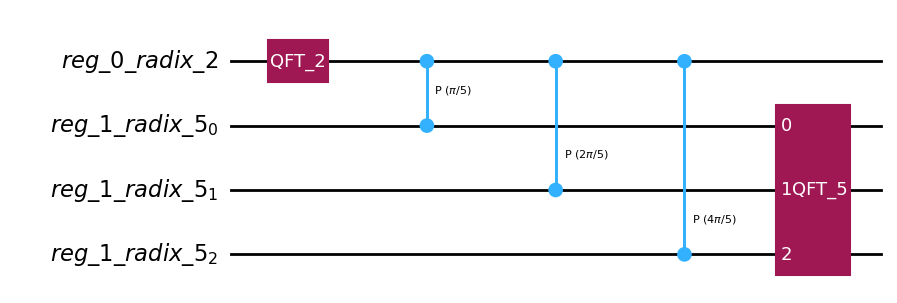

Decomposed circuit depth: 55


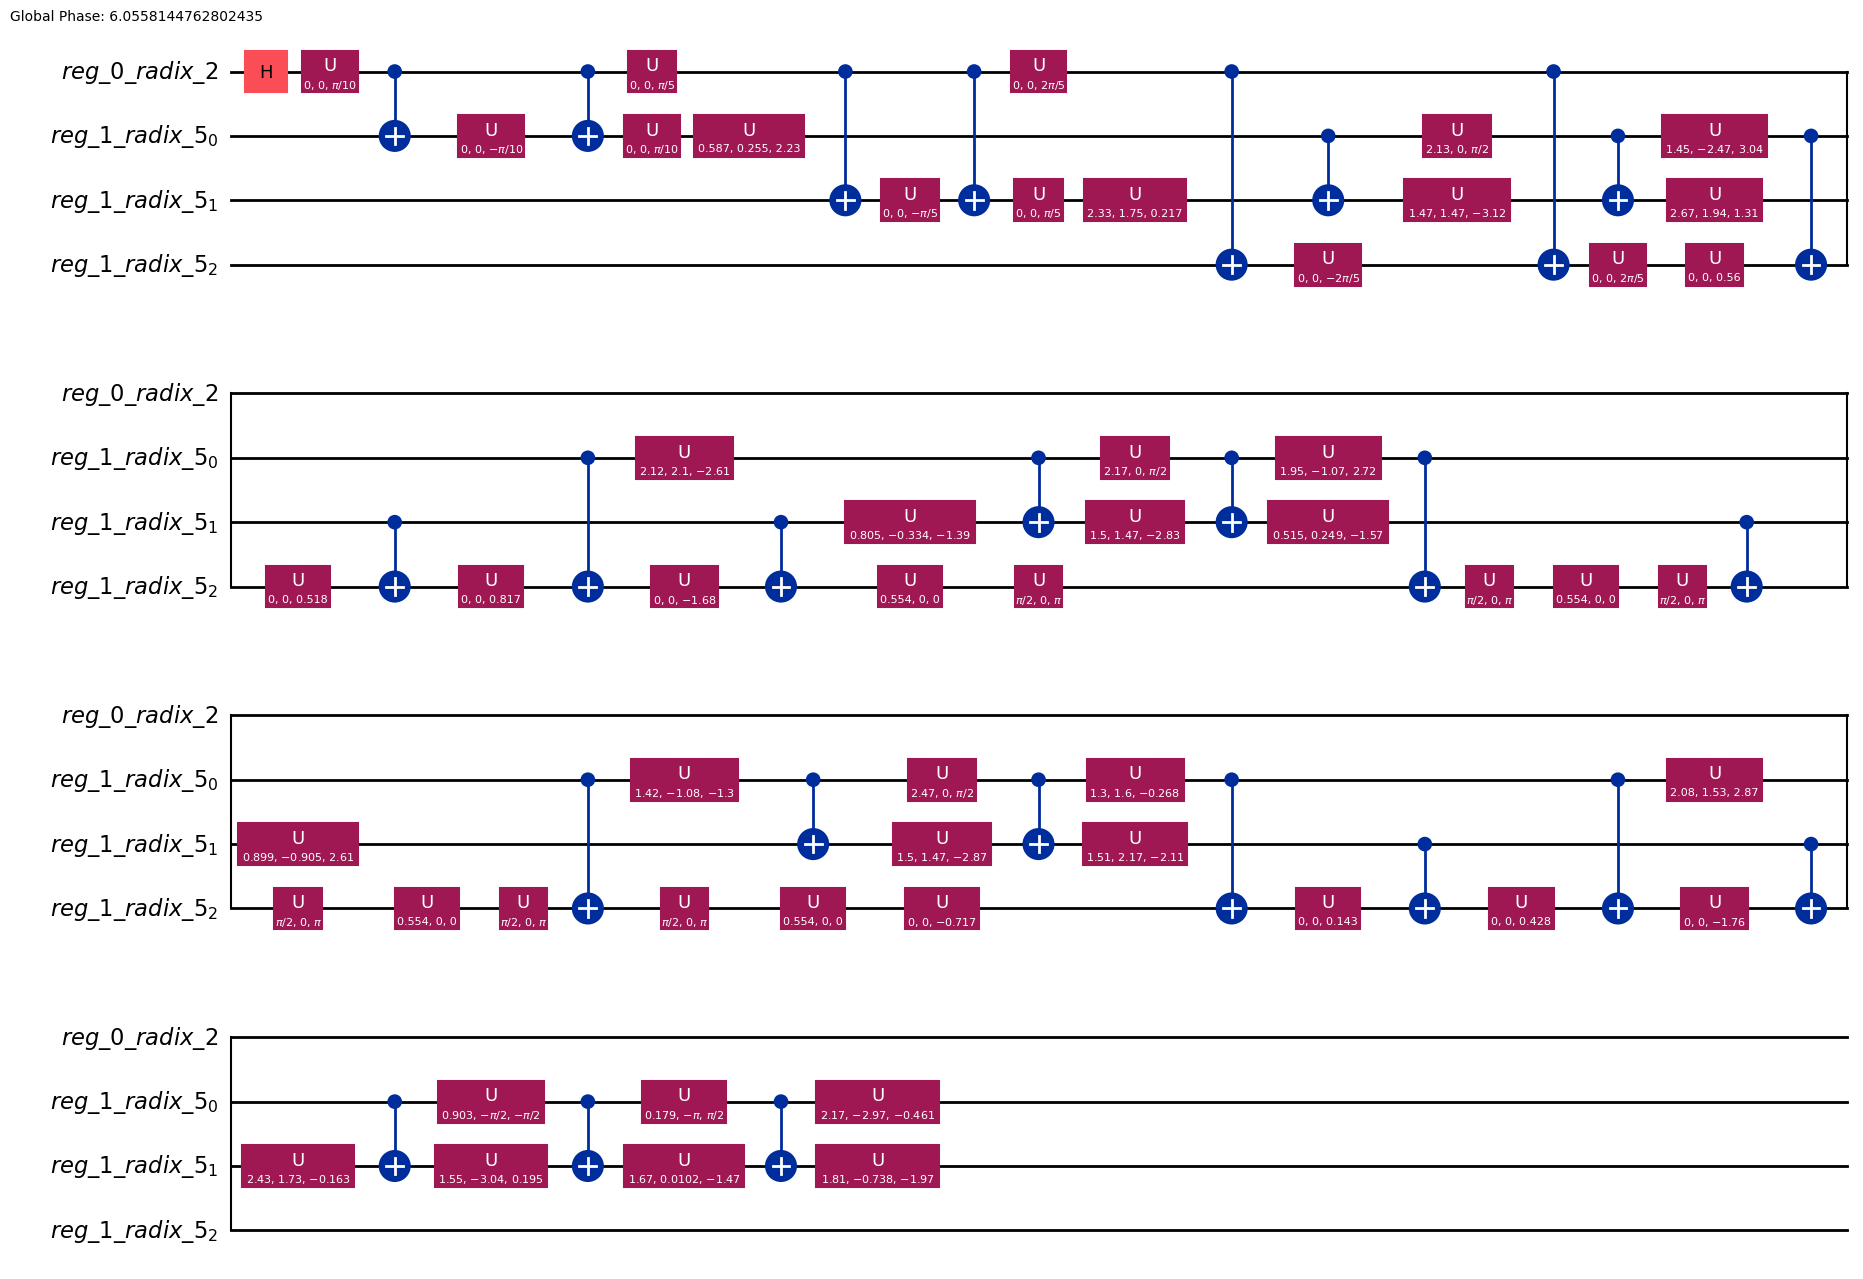

In [138]:
# Copyright: Renata Wong (2026)
# Qiskit code, compatible with Qiskit v.2.0 and later

# This code executes the standard mixed-radix QFT in the reference paper
# A Quantum Bluestein's Algorithm for Arbitrary-Size Quantum Fourier Transform
# Nan-Hong Kuo, and Renata Wong (2025)

import numpy as np
import math
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.circuit.library import QFT, UnitaryGate

def factor_radices(N):
    """Finds the prime factors of N to determine the radices."""
    factors = []
    d = 2
    while d * d <= N:
        while N % d == 0:
            factors.append(d)
            N //= d
        d += 1
    if N > 1:
        factors.append(N)
    return factors

def get_custom_qft_gate(r):
    """
    Synthesizes an exact r x r QFT unitary and embeds it 
    into a binary qubit space, padding with the identity matrix.
    """
    q = math.ceil(math.log2(r))
    dim = 2**q

    # If r is a perfect power of 2, use Qiskit's standard QFT
    if r == dim:
        return QFT(num_qubits=q, do_swaps=False).to_gate(label=f"QFT_{r}")

    # Synthesize the exact r x r DFT matrix
    dft_matrix = np.zeros((r, r), dtype=complex)
    omega = np.exp(2j * np.pi / r)
    for j in range(r):
        for k in range(r):
            dft_matrix[j, k] = (omega ** (j * k)) / np.sqrt(r)

    # Embed into a 2^q x 2^q matrix to protect padded states
    embedded_unitary = np.eye(dim, dtype=complex)
    embedded_unitary[:r, :r] = dft_matrix

    return UnitaryGate(embedded_unitary, label=f"QFT_{r}")

def mixed_radix_qft(N, input_val=None):
    """
    Constructs a mixed-radix QFT circuit for dimension N using 
    the Cooley-Tukey decomposition. Automatically maps an input 
    integer to the correct mixed-radix basis states.
    """
    radices = factor_radices(N)
    
    # Create distinct quantum registers for each radix
    # FIX: Added enumeration to ensure unique register names
    registers = []
    for i, r in enumerate(radices):
        q = math.ceil(math.log2(r))
        registers.append(QuantumRegister(q, name=f"reg_{i}_radix_{r}"))
        
    qc = QuantumCircuit(*registers)

    # --- automated input mapping ---
    if input_val is not None:
        if input_val < 0 or input_val >= N:
            raise ValueError(f"Input must be a valid logical state between 0 and {N-1}")
            
        print(f"Initializing circuit to logical state |{input_val}>")
        temp = input_val
        digits = []
        
        # Decompose the integer into mixed-radix digits (right to left)
        for i in range(len(radices) - 1, -1, -1):
            r = radices[i]
            digits.insert(0, temp % r)
            temp = temp // r
            
        # Apply X gates based on the binary representation of each digit
        qubit_idx = 0
        for i, d in enumerate(digits):
            q = math.ceil(math.log2(radices[i]))
            for bit in range(q):
                if (d >> bit) & 1:
                    qc.x(qubit_idx + bit)
            qubit_idx += q
    # -----------------------------------

    # Cooley-Tukey Algorithm: Interleaved QFTs and Twiddle Factors
    for i in range(len(radices)):
        
        # 1. Apply local QFT to the current radix sub-register
        r_i = radices[i]
        qc.append(get_custom_qft_gate(r_i), registers[i])

        # 2. Apply controlled twiddle phases to all subsequent registers
        for j in range(i + 1, len(radices)):
            r_j = radices[j]
            
            # The phase denominator is the product of all radices from i to j
            denominator = np.prod(radices[i:j+1])
            
            # Apply phase between every bit pair of register i and register j
            for bit_i in range(registers[i].size):
                for bit_j in range(registers[j].size):
                    
                    angle = 2 * np.pi * (2**bit_i) * (2**bit_j) / denominator
                    qc.cp(angle, registers[i][bit_i], registers[j][bit_j])

    return qc, radices, registers






def map_digit_reversed_index(measured_binary, radices):
    """
    Classically remaps the measured binary outcome back to the 
    correct 1D integer, accounting for the mixed-radix digit reversal.
    """
    # Convert the measured binary string into integer values for each register
    reg_values = []
    current_bit = 0
    
    # Read binary string from right to left (Qiskit ordering)
    reversed_binary = measured_binary[::-1] 
    
    for r in radices:
        q = math.ceil(math.log2(r))
        bin_chunk = reversed_binary[current_bit : current_bit + q]
        # Reverse chunk back to normal binary to get integer
        reg_values.append(int(bin_chunk[::-1], 2) if bin_chunk else 0)
        current_bit += q

    # Reconstruct the true 1D index using digit-reversed weighting
    true_index = 0
    multiplier = 1
    # Iterate backwards through the registers
    for i in range(len(radices) - 1, -1, -1):
        true_index += reg_values[i] * multiplier
        multiplier *= radices[i]
        
    return true_index

# --- Example Usage ---
N = 10
input_state = 0
qc, radices, registers = mixed_radix_qft(N, input_state)

print(f"Radices for N={N}:", radices)
print(f"Total Qubits: {qc.num_qubits}")

# View the circuit
display(qc.decompose(reps=0).draw('mpl'))
# Decompose the circuit to view the native gates
decomposed_qc = qc.decompose(reps=2)
print(f"Decomposed circuit depth: {decomposed_qc.depth()}")
display(decomposed_qc.draw('mpl'))

Statevector([0.31622777+0.j, 0.31622777+0.j, 0.31622777+0.j,
             0.31622777+0.j, 0.31622777+0.j, 0.31622777+0.j,
             0.31622777+0.j, 0.31622777+0.j, 0.31622777+0.j,
             0.31622777+0.j, 0.        +0.j, 0.        +0.j,
             0.        +0.j, 0.        +0.j, 0.        +0.j,
             0.        +0.j],
            dims=(2, 2, 2, 2))


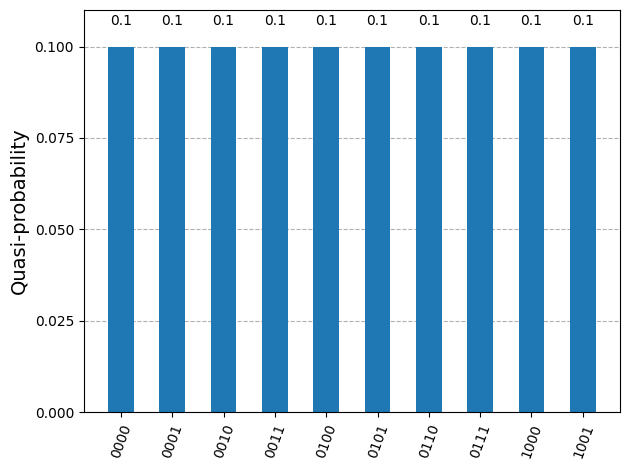

In [139]:
from qiskit.quantum_info import Statevector

# Assume qc is your QuantumCircuit
state = Statevector.from_instruction(qc)

# Print full statevector
print(state)

# Get probabilities
probs = state.probabilities_dict()

# Plot histogram
plot_histogram(probs)

In [140]:
# --- Gate count analysis ---

# 1. Decompose the circuit down to native standard gates (reps=2 usually breaks down unitaries fully)
fully_decomposed_qc = qc.decompose(reps=2)

# 2. Get a dictionary containing the counts of each specific gate type
gate_dict = fully_decomposed_qc.count_ops()

# 3. Calculate the total number of operations
total_gates = sum(gate_dict.values())

print(f"\nCircuit analysis for N={N}:")
print("-" * 40)
print(f"Total gate count: {total_gates}")
print("Gate breakdown:")
for gate_type, count in gate_dict.items():
    print(f"  - {gate_type}: {count}")


Circuit analysis for N=10:
----------------------------------------
Total gate count: 80
Gate breakdown:
  - u: 53
  - cx: 26
  - h: 1


In [88]:
%pip list | grep qiskit

qiskit                  2.1.2
qiskit-addon-sqd        0.12.0
qiskit-addon-utils      0.3.0
qiskit-aer              0.17.2
qiskit-algorithms       0.4.0
qiskit-ibm-runtime      0.41.1
Note: you may need to restart the kernel to use updated packages.
